# Tokyo Station Ridership Prediction

**CS439 — Final Project**

Predicting station-level daily ridership across Tokyo's rail network from network connectivity, geographic, and demographic features.

**Pipeline:**
1. Load and inspect the prepared feature matrix
2. Exploratory data analysis
3. Spatial train/test setup (avoiding spatial leakage)
4. Baseline + Ridge + Random Forest + Gradient Boosting
5. Model comparison and feature importance (SHAP)
6. Error analysis — interpreting under- and over-served stations


## 1. Setup

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10
np.random.seed(42)

## 2. Load Cleaned Data

Load the cleaned feature matrix (595 stations, 14 features + target).

In [36]:
df = pd.read_csv('data/station_features_clean.csv')
df['ward_jp'] = df['ward_jp'].fillna('Outside-23')
print(f'Stations: {len(df)}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Stations: 595
Columns: ['jp_name', 'n_routes', 'daily_stop_events', 'min_transfers_yamanote', 'max_route_btw_cent', 'mean_route_degree_cent', 'mean_route_btw_cent', 'stop_lat', 'stop_lon', 'km_to_yamanote', 'ward_jp', 'pop_800m_catchment', 'ridership_2019', 'log_ridership', 'station_key']


,jp_name,n_routes,daily_stop_events,min_transfers_yamanote,max_route_btw_cent,mean_route_degree_cent,mean_route_btw_cent,stop_lat,stop_lon,km_to_yamanote,ward_jp,pop_800m_catchment,ridership_2019,log_ridership,station_key
0,あざみ野,2.0,1706.0,1.0,0.046516,0.102564,0.028405,35.568292,139.553731,16.338396,Outside-23,0.0,216163.0,12.283793,Azamino
1,お台場海浜公園,1.0,944.0,1.0,0.003140,0.115385,0.003140,35.629900,139.778780,3.322936,港区,17794.0,16899.0,9.735069,Odaiba-kaihinkōen
2,お花茶屋,1.0,498.0,1.0,0.029382,0.141026,0.029382,35.747390,139.839820,6.299938,葛飾区,81269.0,34319.0,10.443484,Ohanajaya
3,たまプラーザ,1.0,1113.0,1.0,0.046516,0.153846,0.046516,35.577407,139.558583,15.511069,Outside-23,0.0,83136.0,11.328245,Tama-plaza
4,つつじヶ丘,1.0,953.0,1.0,0.034354,0.192308,0.034354,35.658000,139.575190,11.410843,Outside-23,66380.0,45169.0,10.718188,Tsutsujigaoka


## 3. Exploratory Data Analysis

### 3.1 Target distribution

We use log transformation to simplify work on ridership, which is heavily right-skewed.

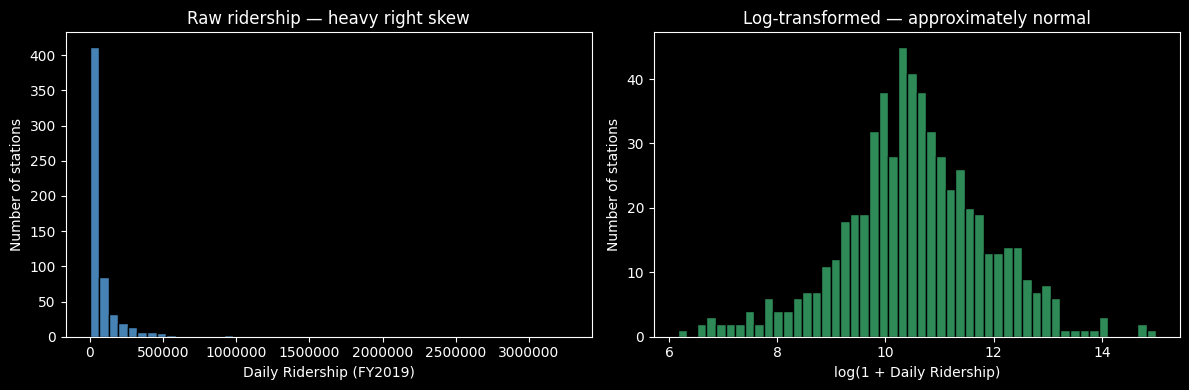


Raw ridership:  min=       473  median=    36,829  max= 3,265,570
Log ridership:  min=6.16  median=10.51  max=15.00


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['ridership_2019'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Daily Ridership (FY2019)')
axes[0].set_ylabel('Number of stations')
axes[0].set_title('Raw ridership — heavy right skew')
axes[0].ticklabel_format(axis='x', style='plain')

axes[1].hist(df['log_ridership'], bins=50, color='seagreen', edgecolor='black')
axes[1].set_xlabel('log(1 + Daily Ridership)')
axes[1].set_ylabel('Number of stations')
axes[1].set_title('Log-transformed — approximately normal')

plt.tight_layout()
plt.show()

print(f'\nRaw ridership:  min={df.ridership_2019.min():>10,.0f}  '
      f'median={df.ridership_2019.median():>10,.0f}  '
      f'max={df.ridership_2019.max():>10,.0f}')
print(f'Log ridership:  min={df.log_ridership.min():.2f}  '
      f'median={df.log_ridership.median():.2f}  '
      f'max={df.log_ridership.max():.2f}')

### 3.2 Feature-target correlations

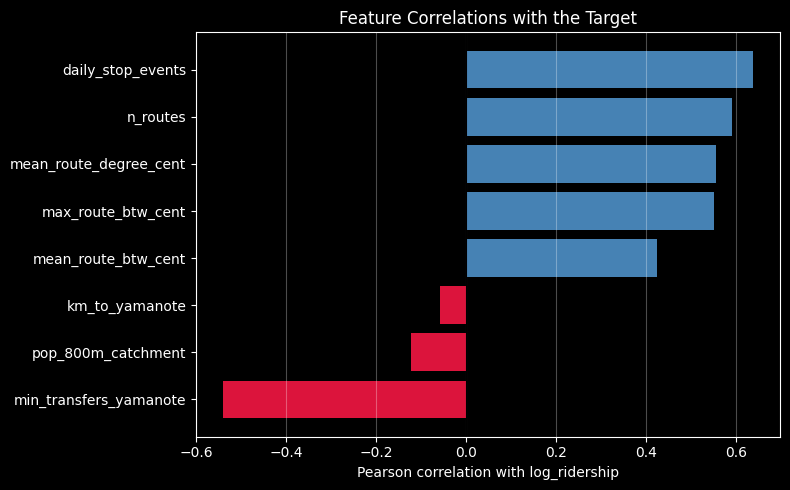


Numerical correlations:
min_transfers_yamanote   -0.542
pop_800m_catchment       -0.122
km_to_yamanote           -0.057
mean_route_btw_cent       0.426
max_route_btw_cent        0.552
mean_route_degree_cent    0.556
n_routes                  0.592
daily_stop_events         0.639


In [38]:
numeric_features = [
    'n_routes', 'min_transfers_yamanote',
    'mean_route_degree_cent', 'mean_route_btw_cent', 'max_route_btw_cent',
    'daily_stop_events', 'km_to_yamanote', 'pop_800m_catchment',
]

corrs = (df[numeric_features + ['log_ridership']]
         .corr()['log_ridership'].drop('log_ridership')
         .sort_values())

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['crimson' if c < 0 else 'steelblue' for c in corrs]
ax.barh(corrs.index, corrs.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with log_ridership')
ax.set_title('Feature Correlations with the Target')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nNumerical correlations:')
print(corrs.round(3).to_string())

### 3.3 Multicollinearity


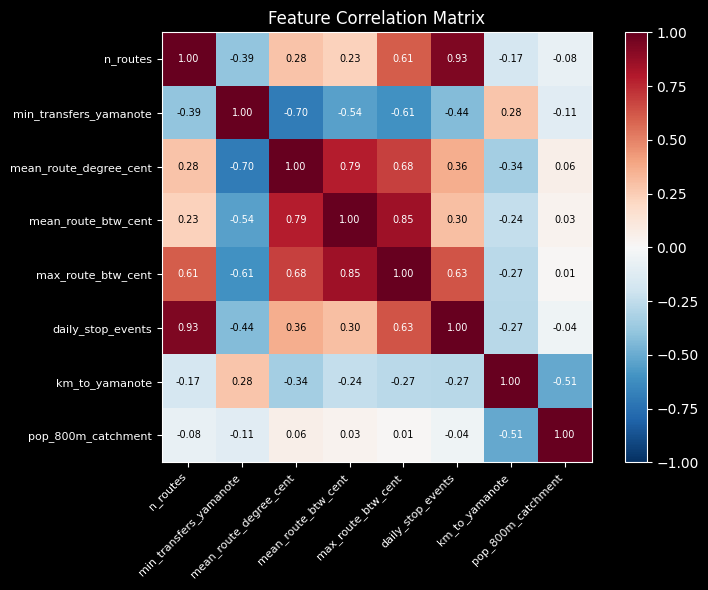

In [39]:
fc = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(fc, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(fc.columns)))
ax.set_yticks(range(len(fc.columns)))
ax.set_xticklabels(fc.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(fc.columns, fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Feature Correlation Matrix')

for i in range(len(fc.columns)):
    for j in range(len(fc.columns)):
        ax.text(j, i, f'{fc.values[i,j]:.2f}', ha='center', va='center',
                color='white' if abs(fc.values[i,j]) > 0.5 else 'black',
                fontsize=7)
plt.tight_layout()
plt.show()

### 3.4 Geographic distribution

Map stations by ridership to see the spatial pattern.

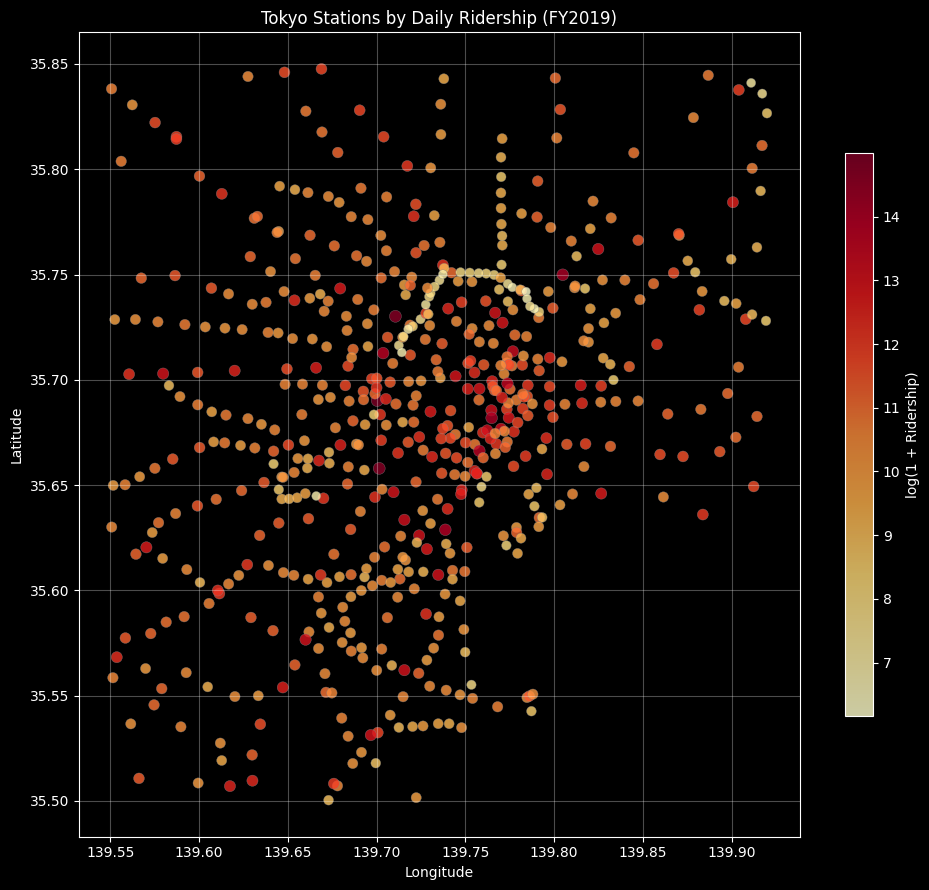

In [40]:
fig, ax = plt.subplots(figsize=(10, 9))
sc = ax.scatter(df.stop_lon, df.stop_lat,
                c=df.log_ridership, cmap='YlOrRd',
                s=15 + df.log_ridership * 4,
                alpha=0.8, edgecolors='grey', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='log(1 + Ridership)', shrink=0.7)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Tokyo Stations by Daily Ridership (FY2019)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Train / Test Setup

### Why spatial cross-validation?

Station ridership has strong **spatial autocorrelation** — neighbouring stations are similar in ridership because they share catchment areas, similar lines, and similar urban contexts. A naive random split would put nearby stations in both train and test, leaking information across the split and inflating test performance.

The fix is **spatial cross-validation**: hold out entire wards as test folds, so the model is always evaluated on geography it has never seen. This gives an honest estimate of how well the model generalises to *new locations*.

In [41]:
# Use ward as the spatial group. Stations outside the 23 wards are grouped
# into one category called Outside-23.
groups = df['ward_jp'].values
print(f'Spatial groups (wards): {df.ward_jp.nunique()}')
print(f'\nStations per group:')
print(df.ward_jp.value_counts().to_string())

Spatial groups (wards): 24

Stations per group:
ward_jp
Outside-23    121
大田区            40
世田谷区           39
港区             32
江東区            28
品川区            26
新宿区            26
豊島区            24
足立区            24
中央区            23
千代田区           21
板橋区            19
荒川区            19
練馬区            19
北区             18
台東区            16
杉並区            16
渋谷区            15
文京区            15
葛飾区            12
中野区            12
江戸川区           11
墨田区            11
目黒区             8


In [42]:
# Build feature matrix X and target y
feature_cols = numeric_features + ['ward_jp']
X = df[feature_cols].copy()
y = df['log_ridership'].values

# Pre-build a column transformer that scales numeric features and
# one-hot encodes ward.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['ward_jp']),
    ]
)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (595, 9)
y shape: (595,)


## 5. Models and Cross-Validation

### Models
1. **Mean predictor (baseline)** — always predicts the training mean
2. **Ridge regression** — linear model, handles multicollinearity
3. **Random Forest** — non-linear, handles interactions
4. **Gradient Boosting** — typically strongest on tabular data

### Evaluation
Spatial group k-fold CV with k = 8. For each model, report mean ± std of:
- **R²** on log-ridership
- **MAE** on log-ridership
- **RMSE on the original scale** (back-transformed for interpretability)

In [43]:
def evaluate_model(name, model, X, y, groups, n_splits=8):
    """Spatial group K-fold cross-validation with multiple metrics."""
    cv = GroupKFold(n_splits=n_splits)
    r2s, maes, rmses_orig = [], [], []

    for train_idx, test_idx in cv.split(X, y, groups):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        r2s.append(r2_score(y_te, pred))
        maes.append(mean_absolute_error(y_te, pred))
        # back-transform for original-scale RMSE
        pred_orig = np.expm1(pred)
        true_orig = np.expm1(y_te)
        rmses_orig.append(np.sqrt(mean_squared_error(true_orig, pred_orig)))

    return {
        'model': name,
        'R2_mean': np.mean(r2s),
        'R2_std':  np.std(r2s),
        'MAE_log_mean': np.mean(maes),
        'MAE_log_std':  np.std(maes),
        'RMSE_orig_mean': np.mean(rmses_orig),
        'RMSE_orig_std':  np.std(rmses_orig),
    }

In [44]:
# Define candidate models — each wrapped in the preprocessor pipeline.
models = {
    'Mean (baseline)': DummyRegressor(strategy='mean'),
    'Ridge':           Ridge(alpha=1.0, random_state=42),
    'Random Forest':   RandomForestRegressor(
                          n_estimators=300, min_samples_leaf=3,
                          n_jobs=-1, random_state=42),
    'Gradient Boost':  GradientBoostingRegressor(
                          n_estimators=300, max_depth=4,
                          learning_rate=0.05, random_state=42),
}

results = []
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('reg', model)])
    res = evaluate_model(name, pipe, X, y, groups)
    results.append(res)
    print(f'{name:18s}  R² = {res["R2_mean"]:.3f} ± {res["R2_std"]:.3f}   '
          f'MAE(log) = {res["MAE_log_mean"]:.3f}   '
          f'RMSE(orig) = {res["RMSE_orig_mean"]:>9,.0f}')

results_df = pd.DataFrame(results)

Mean (baseline)     R² = -0.088 ± 0.077   MAE(log) = 1.035   RMSE(orig) =   213,533
Ridge               R² = 0.527 ± 0.072   MAE(log) = 0.677   RMSE(orig) = 1,535,286
Random Forest       R² = 0.679 ± 0.076   MAE(log) = 0.558   RMSE(orig) =   123,809
Gradient Boost      R² = 0.671 ± 0.107   MAE(log) = 0.561   RMSE(orig) =   123,161


### Visualise model comparison

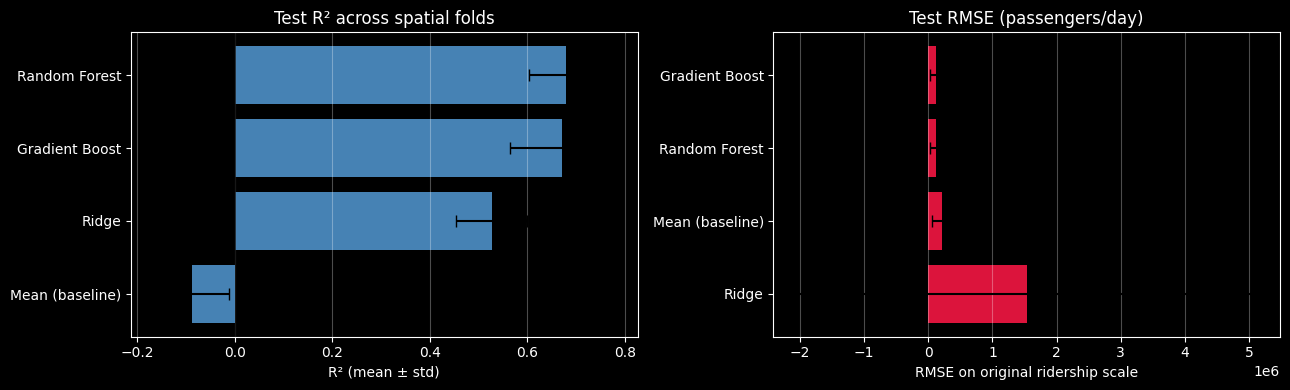

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# R² comparison
order = results_df.sort_values('R2_mean')
axes[0].barh(order['model'], order['R2_mean'],
             xerr=order['R2_std'], color='steelblue',
             error_kw={'capsize': 4})
axes[0].set_xlabel('R² (mean ± std)')
axes[0].set_title('Test R² across spatial folds')
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].grid(axis='x', alpha=0.3)

# RMSE on original scale
order2 = results_df.sort_values('RMSE_orig_mean', ascending=False)
axes[1].barh(order2['model'], order2['RMSE_orig_mean'],
             xerr=order2['RMSE_orig_std'], color='crimson',
             error_kw={'capsize': 4})
axes[1].set_xlabel('RMSE on original ridership scale')
axes[1].set_title('Test RMSE (passengers/day)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Best Model — Detailed Look

We pick the best model by R² and inspect it more carefully.

In [46]:
best_name = results_df.loc[results_df['R2_mean'].idxmax(), 'model']
print(f'Best model: {best_name}')

best_pipe = Pipeline([('prep', preprocessor), ('reg', models[best_name])])

cv = GroupKFold(n_splits=8)
oof_pred = np.zeros(len(y))
for train_idx, test_idx in cv.split(X, y, groups):
    best_pipe.fit(X.iloc[train_idx], y[train_idx])
    oof_pred[test_idx] = best_pipe.predict(X.iloc[test_idx])

df['pred_log']     = oof_pred
df['pred']         = np.expm1(oof_pred)
df['residual_log'] = y - oof_pred

Best model: Random Forest


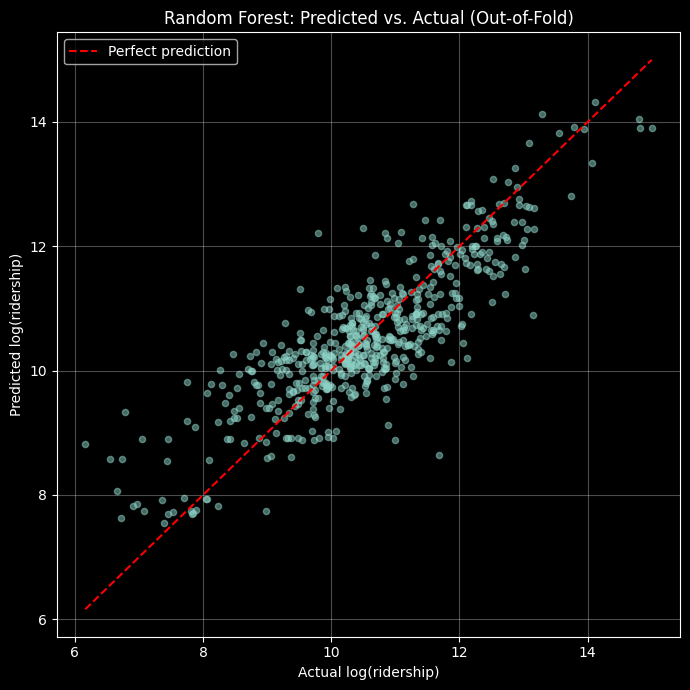


Overall OOF R²: 0.708


In [47]:
# Predicted vs actual
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(df.log_ridership, df.pred_log, alpha=0.5, s=20)
lims = [df.log_ridership.min(), df.log_ridership.max()]
ax.plot(lims, lims, 'r--', label='Perfect prediction')
ax.set_xlabel('Actual log(ridership)')
ax.set_ylabel('Predicted log(ridership)')
ax.set_title(f'{best_name}: Predicted vs. Actual (Out-of-Fold)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nOverall OOF R²: {r2_score(y, oof_pred):.3f}')

## 7. Feature Importance (Tree Importance)

For tree models, feature importance shows which variables drive predictions.

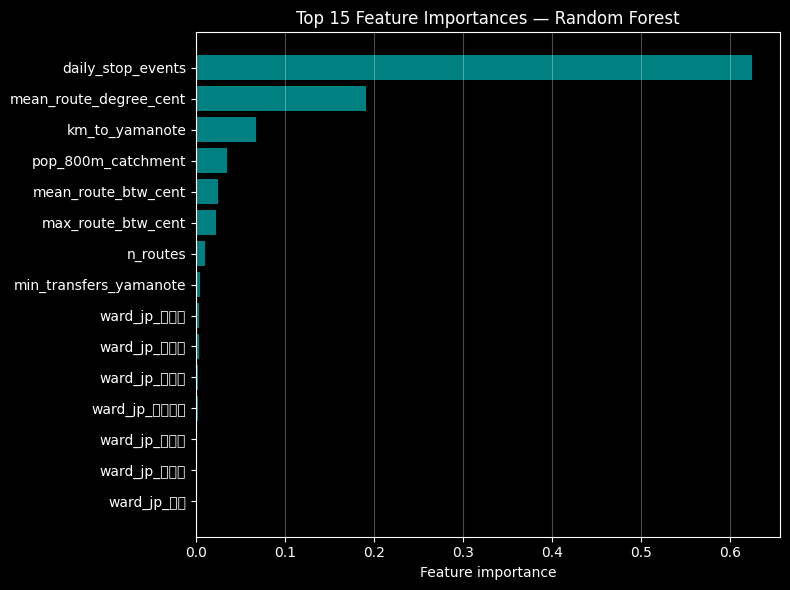

In [48]:
# Refit on all data for importance extraction
final_model = Pipeline([('prep', preprocessor), ('reg', models[best_name])])
final_model.fit(X, y)

if hasattr(final_model.named_steps['reg'], 'feature_importances_'):
    feature_names = (
        numeric_features
        + list(final_model.named_steps['prep']
                          .named_transformers_['cat']
                          .get_feature_names_out(['ward_jp']))
    )
    importances = final_model.named_steps['reg'].feature_importances_
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=True)

    # Show top 15 only
    top15 = imp_df.tail(15)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top15['feature'], top15['importance'], color='teal')
    ax.set_xlabel('Feature importance')
    ax.set_title(f'Top 15 Feature Importances — {best_name}')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_name} does not expose feature_importances_')

## 8. SHAP Analysis

SHAP values give per-prediction feature contributions and a richer picture than tree importance.

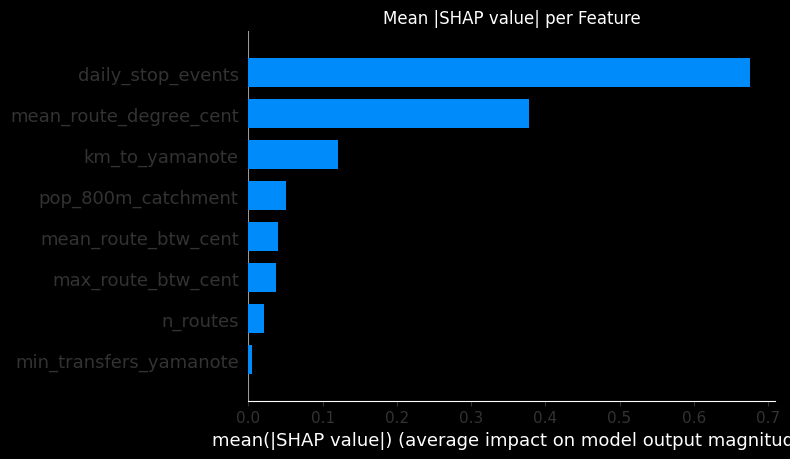

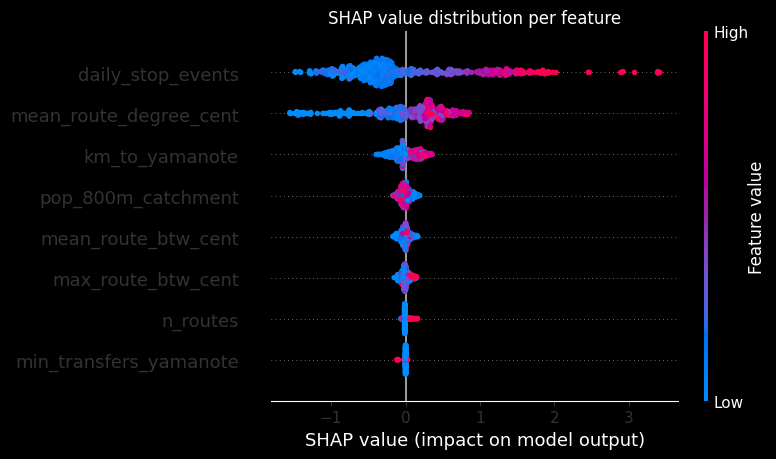

In [49]:
import shap
rf_model = final_model.named_steps['reg']
Xn = X[numeric_features]
Xn_scaled = final_model.named_steps['prep'].named_transformers_['num'].transform(Xn)


rf_numeric = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=3, n_jobs=-1, random_state=42
)
rf_numeric.fit(Xn,y)
explainer = shap.TreeExplainer(rf_numeric)
shap_values = explainer.shap_values(Xn)

shap.summary_plot(shap_values, Xn, plot_type='bar', show=False)
plt.title('Mean |SHAP value| per Feature')
plt.tight_layout(); plt.show()

shap.summary_plot(shap_values, Xn, show=False)
plt.title('SHAP value distribution per feature')
plt.tight_layout(); plt.show()

## 9. Error Analysis — Under-Served and Over-Served Stations

The original framing of this project asked which areas are *underserved* by transit. We've reframed that as a question about prediction residuals:

- Stations with positive residuals have higher actual ridership than their features predict, meaning demand exceeds what the network alone explains. This is likely due to the stations serving popular destinations that isn't captured by the connectivity features (tourist sites, major office clusters, etc.).
- Stations with negative residuals have a lower actual ridership than predicted, meaning demand under-uses the network's capacity. This is likely due to them being under-utilized, perhaps because of demographics or competing access modes.

In [50]:
top_pos = df.nlargest(10, 'residual_log')[
    ['jp_name', 'station_key', 'ward_jp', 'ridership_2019', 'pred', 'residual_log']
].round(2)
print('--- Top 10 stations the model UNDER-predicts (busier than features suggest) ---')
print(top_pos.to_string(index=False))

top_neg = df.nsmallest(10, 'residual_log')[
    ['jp_name', 'station_key', 'ward_jp', 'ridership_2019', 'pred', 'residual_log']
].round(2)
print('\n--- Top 10 stations the model OVER-predicts (quieter than features suggest) ---')
print(top_neg.to_string(index=False))

--- Top 10 stations the model UNDER-predicts (busier than features suggest) ---
 jp_name           station_key    ward_jp  ridership_2019      pred  residual_log
モノレール浜松町 Monorail Hamamatsuchō         港区        117370.0   5673.76          3.03
      京橋              Kyobashi        中央区        512151.0  54187.33          2.25
      栄町              Sakaecho         北区         59984.0   7231.68          2.12
    西武新宿        Seibu-Shinjuku        新宿区        183666.0  26959.35          1.92
    武蔵小山        Musashi-koyama        品川区         53193.0   9180.13          1.76
     北朝霞            Kita-Asaka Outside-23        141768.0  25234.21          1.73
   武蔵溝ノ口   Musashi-Mizonokuchi Outside-23        172692.0  34233.70          1.62
      登戸              Noborito Outside-23        333115.0  76051.30          1.48
     新横浜         Shin-Yokohama Outside-23        269903.0  66374.47          1.40
      綾瀬                 Ayase        足立区        455014.0 112218.89          1.40

--- Top 10 statio

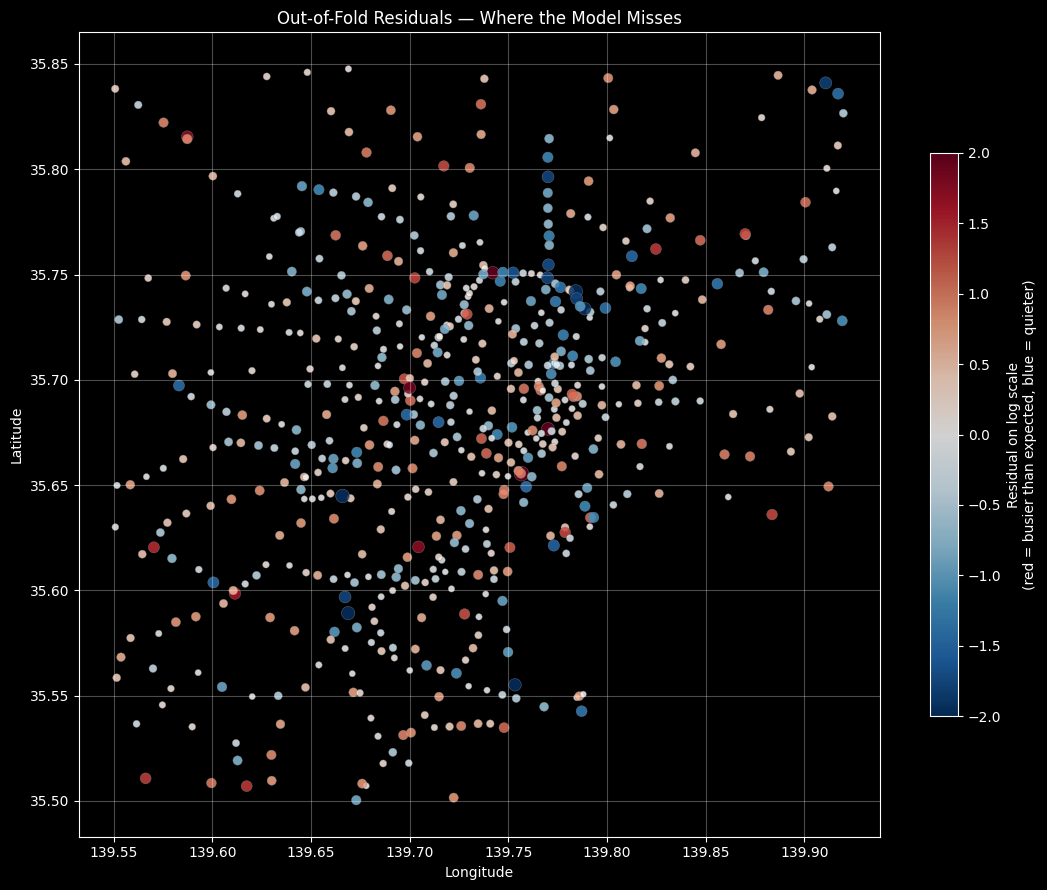

In [51]:
# Map residuals geographically
fig, ax = plt.subplots(figsize=(11, 9))
sc = ax.scatter(df.stop_lon, df.stop_lat,
                c=df.residual_log, cmap='RdBu_r',
                s=20 + np.abs(df.residual_log) * 30,
                vmin=-2, vmax=2, alpha=0.85,
                edgecolors='grey', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='Residual on log scale\n(red = busier than expected, blue = quieter)',
             shrink=0.7)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Out-of-Fold Residuals — Where the Model Misses')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
# Aggregate residuals by ward
ward_resid = (df.groupby('ward_jp')
                .agg(mean_resid=('residual_log', 'mean'),
                     n_stations=('residual_log', 'size'))
                .sort_values('mean_resid'))
print('--- Mean residual by ward ---')
print('(positive = systematically busier than predicted)')
print(ward_resid.round(3).to_string())

--- Mean residual by ward ---
(positive = systematically busier than predicted)
            mean_resid  n_stations
ward_jp                           
荒川区             -0.879          19
台東区             -0.410          16
足立区             -0.329          24
大田区             -0.207          40
北区              -0.115          18
練馬区             -0.095          19
文京区             -0.090          15
板橋区             -0.088          19
世田谷区            -0.078          39
江東区             -0.072          28
墨田区             -0.059          11
豊島区             -0.049          24
中野区             -0.044          12
新宿区             -0.026          26
千代田区            -0.017          21
杉並区              0.013          16
渋谷区              0.071          15
葛飾区              0.150          12
品川区              0.166          26
目黒区              0.176           8
港区               0.224          32
Outside-23       0.251         121
中央区              0.286          23
江戸川区             0.316          11
